<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_3_(tc(ne%2C_Me)).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Множественная регрессия tc(ne, Me)


In [ ]:
!pip install --upgrade patsy statsmodels

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
# Загрузка данных и конвертация в CSV
file_name = '/content/multiregress042020.xlsx'
df = pd.read_excel(file_name, header=1)
csv_file_name = 'multiregress042020.csv'
df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')


# Создаю переменные
X_data = df[['ne', 'Me']]
Y_data = df['tc']

# Добавляем константу
X_sm = sm.add_constant(X_data)

# Проверка перых 3 строк
print(df.head(3))

   i    ne   Me    tc      ge    CO2     NOx
0  1  1200  140  80.7  233.16   5.88  665.25
1  2  1200  210  82.8  225.23   8.67  900.50
2  3  1200  252  83.2  232.83  10.58  957.19


In [ ]:
# Построение модели
model_tc = sm.OLS(Y_data, X_sm).fit()

# Вывод результатов
print(model_tc.summary())

# Дополнительный вывод статистики Дарбина-Уотсона:
dw_stat = sm.stats.stattools.durbin_watson(model_tc.resid)
print(f"\nСтатистика Дарбина-Уотсона: {dw_stat:.3f}")
if 1.5 < dw_stat < 2.5:
    print("Вывод: Автокорреляция остатков отсутствует (значение близко к 2).")
else:
    print("Вывод: Присутствует автокорреляция остатков.")

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     134.8
Date:                Sun, 03 May 2026   Prob (F-statistic):           5.96e-12
Time:                        09:22:08   Log-Likelihood:                -10.882
No. Observations:                  22   AIC:                             27.76
Df Residuals:                      19   BIC:                             31.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.1796      0.650    117.176      0.0

/tmp/ipykernel_1546/555049352.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_surf = model_tc.params[0] + model_tc.params[1]*x_surf + model_tc.params[2]*y_surf


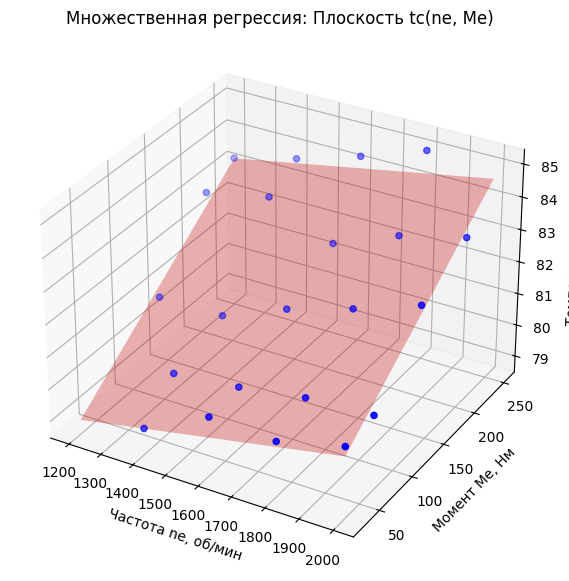

In [ ]:
# Визуализация
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Точки исходных данных
ax.scatter(df['ne'], df['Me'], df['tc'], color='blue', label='Фактические данные')

# Создание сетки для плоскости
x_surf, y_surf = np.meshgrid(np.linspace(df['ne'].min(), df['ne'].max(), 10),
                             np.linspace(df['Me'].min(), df['Me'].max(), 10))
z_surf = model_tc.params[0] + model_tc.params[1]*x_surf + model_tc.params[2]*y_surf

# Отрисовка плоскости
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3)

ax.set_xlabel('Частота ne, об/мин')
ax.set_ylabel('Момент Me, Нм')
ax.set_zlabel('Температура tc, °C')
plt.title('Множественная регрессия: Плоскость tc(ne, Me)')
plt.show()